In [1]:
import re

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
sales_df = pd.read_csv(
    "../assets/stores_sales_forecasting_data.csv",
    encoding="Latin1",
)

# Section 1 - Data Cleaning & Validation

In [3]:
# Check for NaNs in this dataset (there are none, since this dataset is pristine practice data)
assert len(sales_df.dropna(how="any")) == len(sales_df)

In [4]:
# Look for duplicates
# There is a record that's duplicated, we will come back to this below when we look at returns.
sales_df[sales_df.drop(columns="Row ID").duplicated(keep=False)]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Avg_Region_Sales,Avg_City_Sales
719,3406,US-2014-150119,4/23/2014,4/27/2014,Standard Class,LB-16795,Laurel Beltran,Home Office,United States,Columbus,...,FUR-CH-10002965,Furniture,Chairs,Global Leather Highback Executive Chair with P...,281.372,2,0.3,-12.0588,333.55,196.55
720,3407,US-2014-150119,4/23/2014,4/27/2014,Standard Class,LB-16795,Laurel Beltran,Home Office,United States,Columbus,...,FUR-CH-10002965,Furniture,Chairs,Global Leather Highback Executive Chair with P...,281.372,2,0.3,-12.0588,333.55,196.55


In [5]:
# Convert the column names because spaces and capitals are annoying
sales_df.columns = [
    re.sub(
        r" +",
        "_",
        re.sub(r"\(.*?\)", "", c.lower().replace("/", " ").replace("-", "_")).strip(),
    )
    for c in sales_df.columns
]

In [6]:
len(  # Check if the avg. region sales column is just the overall average for the whole dataset.
    sales_df.groupby("region")
    .sales.mean()
    .round(2)
    .reset_index()
    .merge(
        sales_df[["region", "avg_region_sales"]].drop_duplicates(),
        how="outer",
        indicator=True,
    )
    .query('_merge == "left_only"')
    .drop(columns="_merge")
) == 0

True

In [7]:
len(  # Check if the avg. city sales column is just the overall average for the whole dataset.
    sales_df.groupby("city")
    .sales.mean()
    .round(2)
    .reset_index()
    .merge(
        sales_df[["city", "avg_city_sales"]].drop_duplicates(),
        how="outer",
        indicator=True,
    )
    .query('_merge == "left_only"')
    .drop(columns="_merge")
) == 0

True

Since these fields contain information about the entire dataset, we can't include them in our model because it will result in data leakage.

### Look for product IDs that refer to different products

In [8]:
multiples = (
    sales_df.groupby("product_id")["product_name"]
    .agg(name_count=lambda x: len(set(x)), name_set=lambda x: set(x))
    .reset_index()
)
multiples = multiples[multiples.name_count > 1]
multiples

,product_id,name_count,name_set
18,FUR-BO-10002213,2,"{DMI Eclipse Executive Suite Bookcases, Sauder..."
65,FUR-CH-10001146,2,"{Global Task Chair, Black, Global Value Mid-Ba..."
183,FUR-FU-10001473,2,"{Eldon Executive Woodline II Desk Accessories,..."
284,FUR-FU-10004017,2,{Tenex Contemporary Contur Chairmats for Low a...
290,FUR-FU-10004091,2,"{Eldon 200 Class Desk Accessories, Black, Howa..."
295,FUR-FU-10004270,2,"{Eldon Image Series Desk Accessories, Burgundy..."
310,FUR-FU-10004848,2,"{Howard Miller 13-3/4"" Diameter Brushed Chrome..."
311,FUR-FU-10004864,2,"{Eldon 500 Class Desk Accessories, Howard Mill..."


We should let the client know that their system has a coding error where certain product ids refer to different products. For now, let's add _n to the ids to differentiate them.

Using the new product ID, we can then add in the price per item. 

In [9]:
sales_df_unique = (
    sales_df[["product_id", "product_name"]]
    .drop_duplicates()
    .assign(
        product_id_new=lambda x: (
            x["product_id"].astype(str)
            + "_"
            + x.groupby("product_id").cumcount().astype(str)
        )
    )
)

sales_df = sales_df.merge(
    sales_df_unique, on=["product_id", "product_name"], how="left"
)


# Add a column for item price
sales_df["item_price"] = (
    sales_df["sales"] / sales_df["quantity"] / (1 - sales_df["discount"])
).round(2)

In [10]:
# Verify that item pricing is consistent
prices = sales_df[["product_id_new", "item_price"]].drop_duplicates()
assert len(prices[prices.product_id_new.duplicated(keep=False)]) == 0

In [11]:
# Replace the product_id with the new one.
sales_df = sales_df.drop(columns="product_id").rename(
    columns={"product_id_new": "product_id"}
)

In [12]:
sales_df

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,sub_category,product_name,sales,quantity,discount,profit,avg_region_sales,avg_city_sales,product_id,item_price
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,344.42,448.55,FUR-BO-10001798_0,130.98
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,344.42,448.55,FUR-CH-10000454_0,243.98
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,344.42,415.44,FUR-TA-10000577_0,348.21
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694,334.26,332.55,FUR-FU-10001487_0,6.98
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092,334.26,332.55,FUR-TA-10001539_0,236.97
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2179,10050,CA-2014-131247,04/04/2014,04/04/2014,Standard Class,GA-14725,Guy Armstrong,Consumer,United States,San Francisco,...,Bookcases,O'Sullivan Living Dimensions 2-Shelf Bookcases,-205.6660,-2,0.15,12.0980,334.26,340.14,FUR-BO-10001337_0,120.98
2180,10051,CA-2017-166142,07/20/2017,07/20/2017,Standard Class,MM-17260,Magdelene Morse,Consumer,United States,Wilmington,...,Tables,Hon 2111 Invitation Series Straight Table,-310.4430,-3,0.30,48.7839,333.55,403.64,FUR-TA-10004607_0,147.83
2181,10052,CA-2014-117765,09/12/2014,09/12/2014,Standard Class,RB-19465,Rick Bensley,Home Office,United States,Tulsa,...,Chairs,"Padded Folding Chairs, Black, 4/Carton",-161.9600,-2,0.00,-45.3488,322.30,495.20,FUR-CH-10004698_0,80.98
2182,10053,CA-2017-147228,09/14/2017,09/14/2017,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Columbia,...,Furnishings,Eldon Wave Desk Accessories,-14.1360,-3,0.20,-4.2408,344.42,467.49,FUR-FU-10000023_0,5.89


<Axes: xlabel='profit', ylabel='Count'>

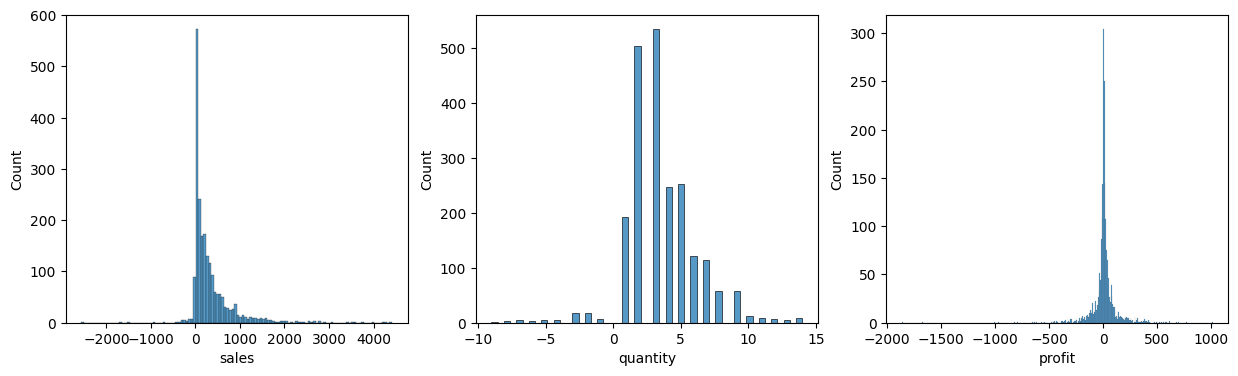

In [13]:
# We can see that there are negative quantities and sales and in the data. Most likely representing returns.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(sales_df.sales, ax=axes[0])
sns.histplot(sales_df.quantity, ax=axes[1])
sns.histplot(sales_df.profit, ax=axes[2])

In [14]:
# Look for records where there are multiple rows for the same product id per order.
returns = sales_df[
    sales_df.duplicated(subset=["order_id", "product_id"], keep=False)
].sort_values("order_id")

# See if any of the flagged rows don't balance
flagged = (
    returns.groupby(["product_id", "order_id"])[["quantity", "profit", "sales"]]
    .sum()
    .sort_values(by="sales", ascending=False)
)
flagged[(flagged.quantity != 0) | (flagged.profit != 0) | (flagged.sales != 0)]

,,quantity,profit,sales
product_id,order_id,,,
FUR-FU-10003664_0,CA-2016-137043,9,249.1506,859.140
FUR-CH-10002965_0,US-2014-150119,4,-24.1176,562.744


In [15]:
# Most of what we flagged as returns balance to 0, but there are two orders where they don't so let's investigate.
returns[(returns["order_id"] == "CA-2016-137043")]

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,sub_category,product_name,sales,quantity,discount,profit,avg_region_sales,avg_city_sales,product_id,item_price
270,1302,CA-2016-137043,12/23/2016,12/25/2016,Second Class,LC-17140,Logan Currie,Consumer,United States,Springfield,...,Furnishings,"Electrix Architect's Clamp-On Swing Arm Lamp, ...",286.38,3,0.0,83.0502,344.42,429.88,FUR-FU-10003664_0,95.46
269,1301,CA-2016-137043,12/23/2016,12/25/2016,Second Class,LC-17140,Logan Currie,Consumer,United States,Springfield,...,Furnishings,"Electrix Architect's Clamp-On Swing Arm Lamp, ...",572.76,6,0.0,166.1004,344.42,429.88,FUR-FU-10003664_0,95.46


In [16]:
returns[(returns["order_id"] == "US-2014-150119")]

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,sub_category,product_name,sales,quantity,discount,profit,avg_region_sales,avg_city_sales,product_id,item_price
720,3407,US-2014-150119,4/23/2014,4/27/2014,Standard Class,LB-16795,Laurel Beltran,Home Office,United States,Columbus,...,Chairs,Global Leather Highback Executive Chair with P...,281.372,2,0.3,-12.0588,333.55,196.55,FUR-CH-10002965_0,200.98
719,3406,US-2014-150119,4/23/2014,4/27/2014,Standard Class,LB-16795,Laurel Beltran,Home Office,United States,Columbus,...,Chairs,Global Leather Highback Executive Chair with P...,281.372,2,0.3,-12.0588,333.55,196.55,FUR-CH-10002965_0,200.98


In [17]:
print(
    f"Percent of Records that are returns: {round(len(sales_df[sales_df.quantity < 0]) / len(sales_df) * 100, 2)}%"
)

Percent of Records that are returns: 2.88%


We would need to talk to the client to learn more about their sales tracking system. We don't know if 
when the customer adds items to their order, the system tracks them in a new line, or if if these rows represent errors that we need to get rid of. 

For now, we will assume that all lines do represent actual items sold and do a group-by to get one line per order/product/customer combo.

This will remove lines for subsequent returns and make it so we only consider sales that "held" when predicting future sales. If there were lots of returns in the dataset (currently only 2.88% of records), we could suggest to the client that we do an analysis to see if we can find why certain items might get frequently returned. This approach also means that if in future cases, a customer only returned some of the items they ordered, we would get the net quantity sold.

In [18]:
# Drop row_id, avg_region_salse, and avg_city_sales since they don't help us much.
sales_df = sales_df.drop(columns=["row_id", "avg_region_sales", "avg_city_sales"])
# Convert the dates to DateTime types
sales_df["order_date"] = pd.to_datetime(sales_df["order_date"], format="%m/%d/%Y")
sales_df["ship_date"] = pd.to_datetime(sales_df["ship_date"], format="%m/%d/%Y")

In [19]:
sales_df = (
    sales_df.groupby(
        [
            "order_id",
            "customer_id",
            "customer_name",
            "segment",
            "country",
            "city",
            "state",
            "postal_code",
            "region",
            "product_id",
            "category",
            "sub_category",
            "product_name",
        ]
    )
    .agg(
        {
            "sales": "sum",
            "quantity": "sum",
            "profit": "sum",
            "discount": "mean",
            "order_date": "min",
            "ship_date": "min",
        }
    )
    .reset_index()
)

# Remove the 0 rows that have been balanced out.
sales_df = sales_df[sales_df.quantity > 0]

In [20]:
sales_df

,order_id,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,profit,discount,order_date,ship_date
0,CA-2014-100090,EB-13705,Ed Braxton,Corporate,United States,San Francisco,California,94122,West,FUR-TA-10003715_0,Furniture,Tables,Hon 2111 Invitation Series Corner Table,502.488,3,-87.9354,0.2,2014-07-08,2014-07-12
1,CA-2014-100678,KM-16720,Kunst Miller,Consumer,United States,Houston,Texas,77095,Central,FUR-CH-10002602_0,Furniture,Chairs,DMI Arturo Collection Mission-style Design Woo...,317.058,3,-18.1176,0.3,2014-04-18,2014-04-22
2,CA-2014-100706,LE-16810,Laurel Elliston,Consumer,United States,Springfield,Virginia,22153,South,FUR-FU-10002268_0,Furniture,Furnishings,Ultra Door Push Plate,29.460,6,9.7218,0.0,2014-12-16,2014-12-18
3,CA-2014-100916,FH-14275,Frank Hawley,Corporate,United States,Newport News,Virginia,23602,South,FUR-TA-10004607_0,Furniture,Tables,Hon 2111 Invitation Series Straight Table,591.320,4,112.3508,0.0,2014-10-21,2014-10-26
4,CA-2014-101462,BP-11230,Benjamin Patterson,Consumer,United States,Los Angeles,California,90045,West,FUR-FU-10000409_0,Furniture,Furnishings,"GE 4 Foot Flourescent Tube, 40 Watt",59.920,4,27.5632,0.0,2014-04-20,2014-04-25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2114,US-2017-167318,GZ-14545,George Zrebassa,Corporate,United States,Los Angeles,California,90036,West,FUR-CH-10000665_0,Furniture,Chairs,"Global Airflow Leather Mesh Back Chair, Black",362.352,3,45.2940,0.2,2017-07-26,2017-08-01
2115,US-2017-167402,CP-12085,Cathy Prescott,Corporate,United States,Springfield,Missouri,65807,Central,FUR-BO-10001608_0,Furniture,Bookcases,"Hon Metal Bookcases, Black",212.940,3,53.2350,0.0,2017-01-13,2017-01-18
2116,US-2017-167570,EG-13900,Emily Grady,Consumer,United States,Philadelphia,Pennsylvania,19140,East,FUR-CH-10003396_0,Furniture,Chairs,Global Deluxe Steno Chair,215.544,4,-58.5048,0.3,2017-12-08,2017-12-15
2117,US-2017-168613,GM-14440,Gary McGarr,Consumer,United States,New York City,New York,10009,East,FUR-CH-10002372_0,Furniture,Chairs,Office Star - Ergonomically Designed Knee Chair,145.764,2,3.2392,0.1,2017-10-08,2017-10-14


<Axes: xlabel='profit', ylabel='Count'>

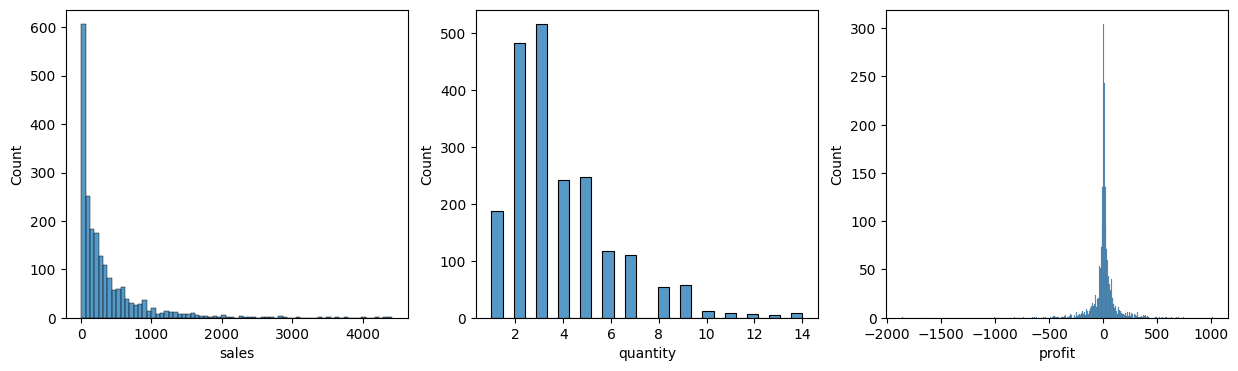

In [21]:
# Check again and see that sales are all now > 0.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(sales_df.sales, ax=axes[0])
sns.histplot(sales_df.quantity, ax=axes[1])
sns.histplot(sales_df.profit, ax=axes[2])

Looking at the number of months with data per group justifies focussing on sub-category and leaving region for now.

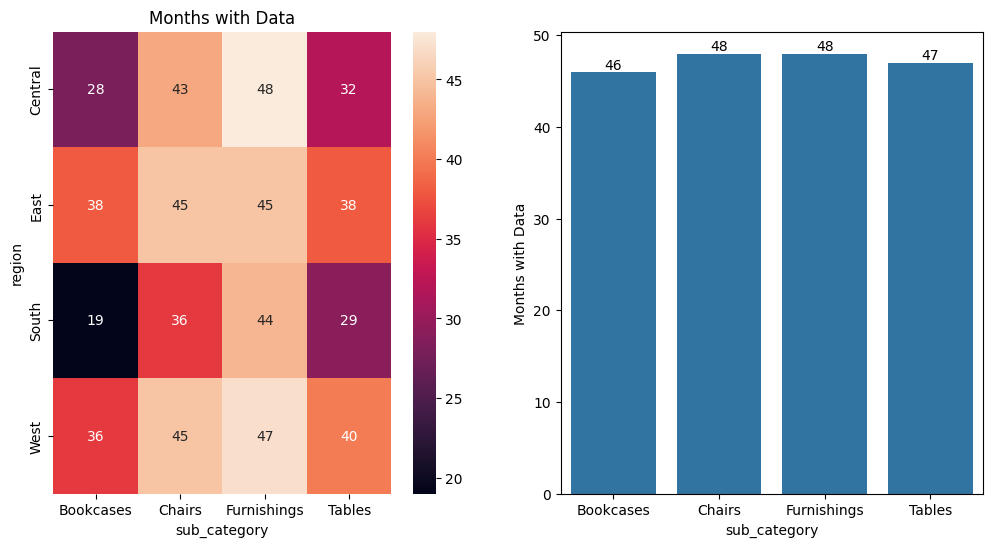

In [22]:
import matplotlib.patches as mpatches

sales_df["year_month"] = sales_df["order_date"].dt.to_period("M")
plot_df = (
    sales_df[["year_month", "sub_category", "region"]]
    .groupby(["sub_category", "region"])
    .nunique()
    .reset_index()
)
plot_df = plot_df.pivot(columns="sub_category", index="region", values="year_month")

fix, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.heatmap(plot_df, annot=True, ax=axes[0]).set_title("Months with Data")

plot_df = sales_df.groupby("sub_category").year_month.nunique().reset_index()
sns.barplot(plot_df, x="sub_category", y="year_month", ax=axes[1]).set_ylabel(
    "Months with Data"
)
axes[1].bar_label(axes[1].containers[0], fmt="%.0f")

plt.show()

# Section 2 - Exploratory Data Analysis / Feature Engineering

Because there really isn't enough data to predict sales for region x subcategory or for specific products, I'm going to define the target output as predicting the total sales per subcategory in a given month. So long as we make sure to chose features that store managers would know in advance, this will help them to manage inventory to match predicted sales volume. I'm also going to try and leave discount as a predictor to help store managers plan how to effectively use discounts to maximize sales.

In [23]:
# Aggregate to monthly x sub-category level data
monthly = (
    sales_df.assign(month=sales_df["order_date"].dt.to_period("M"))
    .groupby(["month", "sub_category"], as_index=False)
    .agg(
        # Sales implicitly includes info on quantity already, so we won't that one it as a predictor.
        # With such a small amount of data, we also want to limit predictors to avoid overfitting.
        sales=("sales", "sum"),
        discount_mean=("discount", "mean"),
    )
)
# convert back to timestamp for plotting
monthly["month"] = monthly["month"].dt.to_timestamp()

In [24]:
monthly

,month,sub_category,sales,discount_mean
0,2014-01-01,Bookcases,1010.0550,0.300000
1,2014-01-01,Chairs,4187.7000,0.000000
2,2014-01-01,Furnishings,711.7700,0.090909
3,2014-02-01,Chairs,190.4580,0.100000
4,2014-02-01,Furnishings,392.9800,0.150000
...,...,...,...,...
184,2017-11-01,Tables,13658.6880,0.252941
185,2017-12-01,Bookcases,3654.0978,0.230833
186,2017-12-01,Chairs,14663.5180,0.141935
187,2017-12-01,Furnishings,4034.2080,0.171429


## Look for possible seasonality by plotting the monthly data

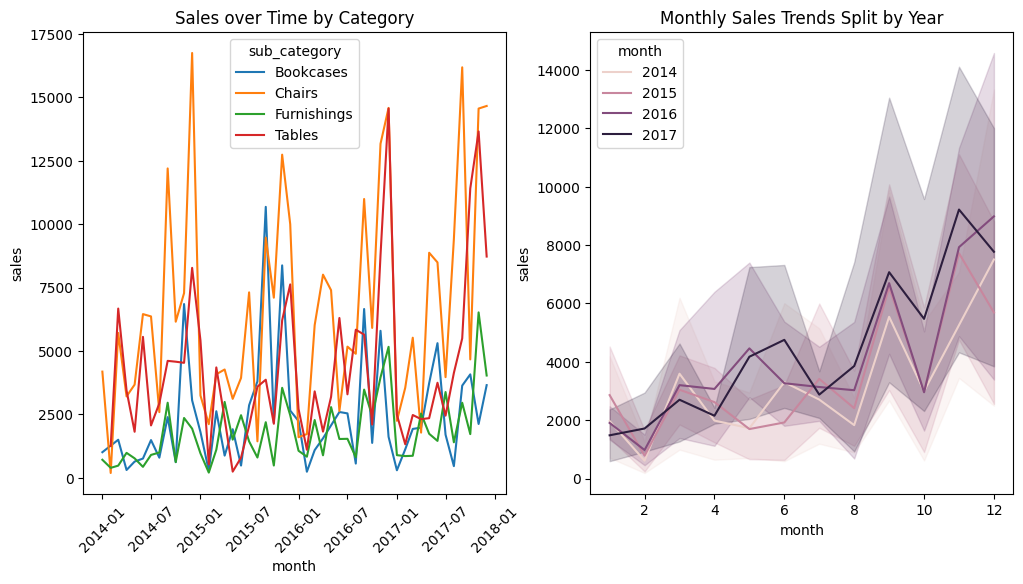

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.lineplot(monthly, x="month", y="sales", hue="sub_category", ax=axes[0]).set_title(
    "Sales over Time by Category"
)
sns.lineplot(
    monthly,
    x=monthly.month.dt.month,
    y="sales",
    hue=monthly.month.dt.year,
    legend=True,
    ax=axes[1],
).set_title("Monthly Sales Trends Split by Year")

axes[0].tick_params(axis="x", rotation=45)

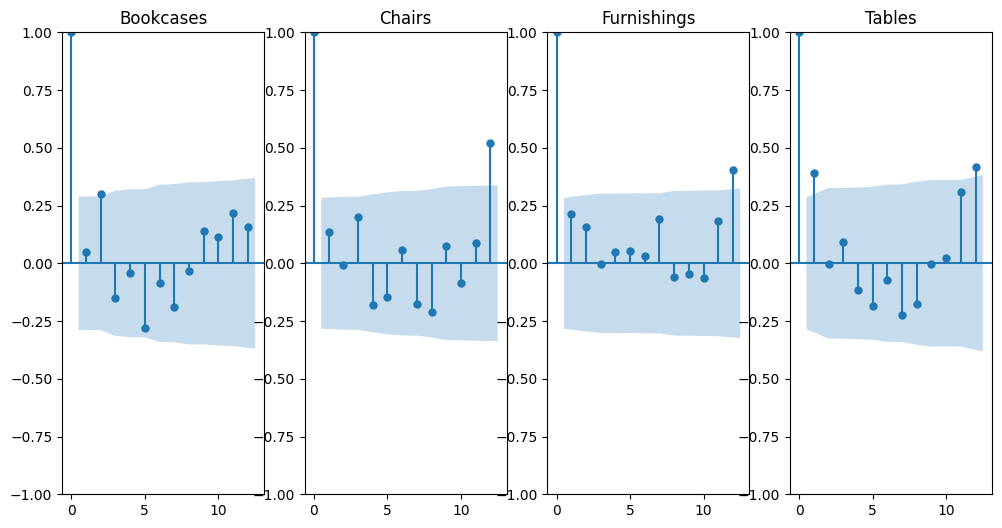

In [26]:
# Let's do some ACF plots to figure out which lags have the biggest correlations
from statsmodels.graphics.tsaplots import plot_acf

monthly = monthly.sort_values(["month", "sub_category"])
fig, axes = plt.subplots(1, 4, figsize=(12, 6))
for cat, ax in zip(monthly.sub_category.unique(), axes):
    plot_acf(monthly[monthly["sub_category"] == cat]["sales"], ax=ax, lags=12)
    ax.set_title(f"{cat}")

Based on ACF, it looks like lag 12 will be important for chairs and furnishings, lag 1 will be important for furnishings and tables. With more time, I would play around with either building separate models for the different categories or selecting a more complicated model where different lags can have different predictive weighting for the different categories. 

In [27]:
monthly = monthly.sort_values(["sub_category", "month"])
# The peak in months like sep seems fairly concistent so we'll stick with sales lag 1 for momentum and then convert month to cos/sin for monthly info.
monthly["sales_lag_1"] = monthly.groupby("sub_category")["sales"].shift(1)
monthly["sales_lag_12"] = monthly.groupby("sub_category")["sales"].shift(12)

monthly = monthly.dropna(subset=["sales_lag_1", "sales_lag_12"])
monthly["month_int"] = monthly["month"].dt.month

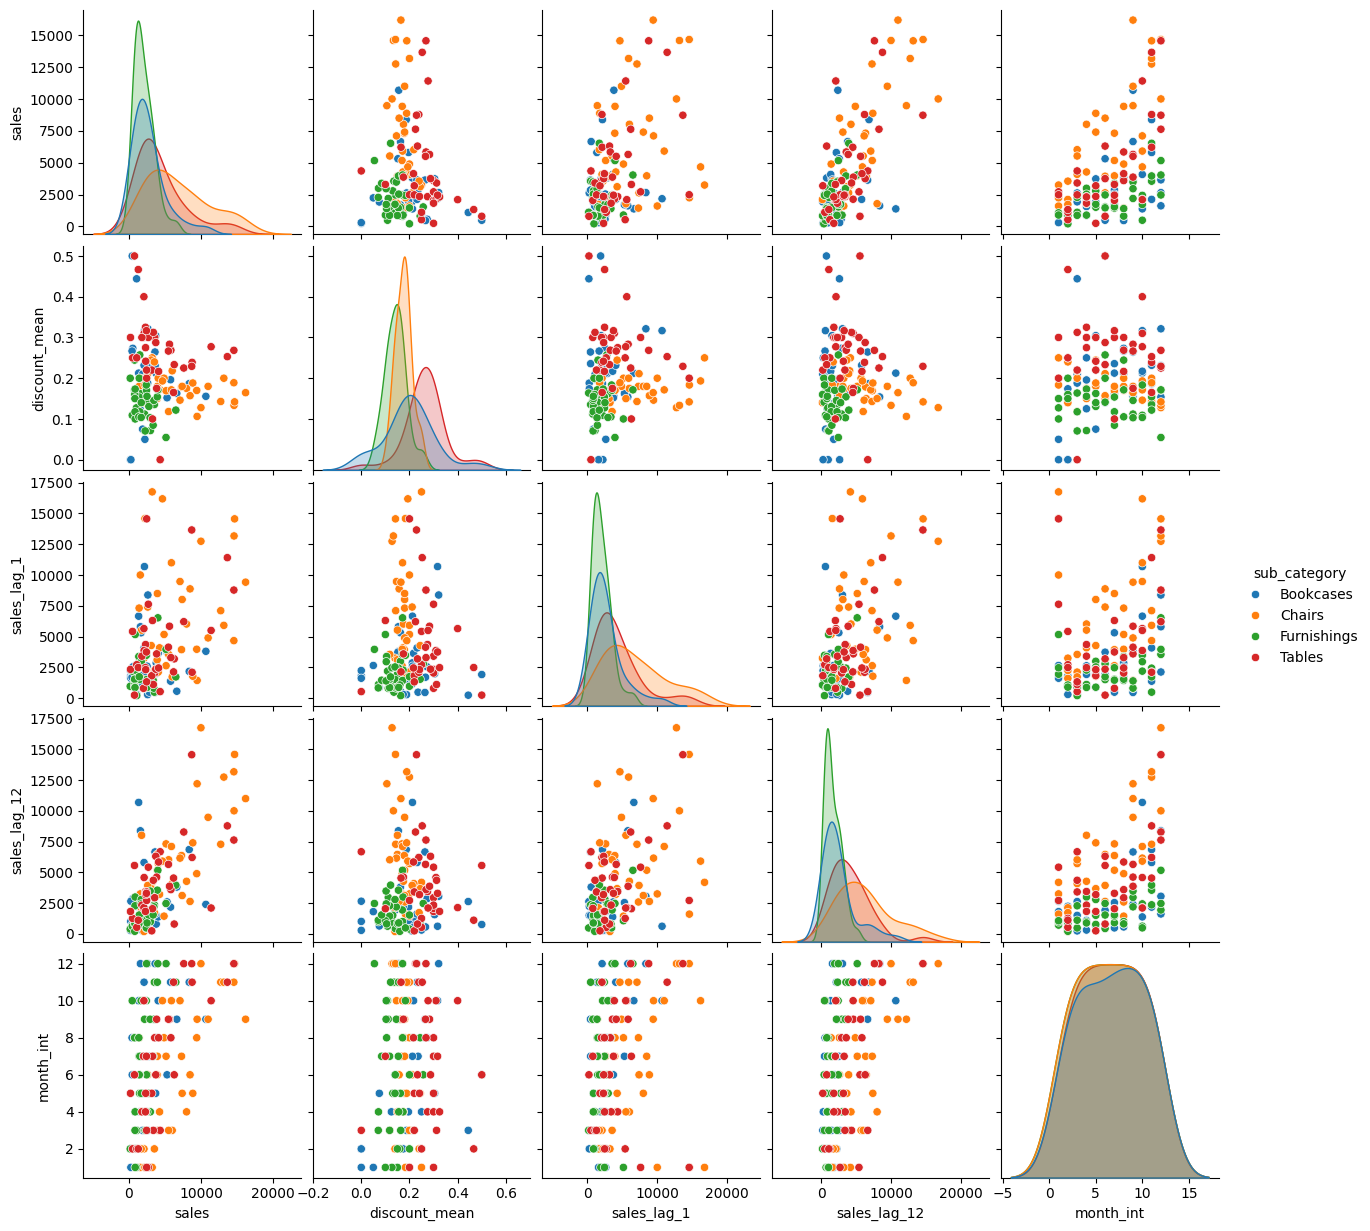

In [28]:
sns.pairplot(
    monthly.drop(columns=["month"]),
    hue="sub_category",
)

Looking at the pairplots, sales_lag_1 is likely to be the most valuable, but we will try a tree based design and look at feature importance in case other features have a non-linear effect. If I had more time I would do a more iterative approach trying to identify better features.

# Section 3 - Modelling

Target: Use historic sales and store manager's selected average discount level for the month to forecast sales in future months. This way a store manager can use accessible historic data and then play with the discount level when forecasting sales.

In [29]:
# One-hot encode sub_category (drop_first=True to avoid multicollinearity)
monthly = pd.get_dummies(monthly, columns=["sub_category"], drop_first=True)

# Feature columns
FEAT_COLS = [
    "sales_lag_1",
    "sales_lag_12",
    "month_int",
    "discount_mean",
] + [c for c in monthly.columns if c.startswith("sub_category_")]

# Train/test split — time-based, never shuffle time series
train = monthly[monthly["month"].dt.year < 2017]
test = monthly[monthly["month"].dt.year == 2017]

X_train, y_train = train[FEAT_COLS], train["sales"]
X_test, y_test = test[FEAT_COLS], test["sales"]

In [30]:
# Let's try a tree based model since our output variable isn't normal, and most of our predictors don't
# appear to have linear effects.
# It is still simple and will be easy to explain to the client.
# If I had more time/data I would explore options like Prophet that is designed specifically for forecasting.
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# Now evaluate the model on the test data
preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
mask = y_test > 0
mape = np.mean(np.abs((y_test[mask] - preds[mask]) / y_test[mask])) * 100

print("Random Forest Results:")
print(f"MAE  : ${mae:,.0f}")
print(f"RMSE : ${rmse:,.0f}")
print(f"MAPE : {mape:.1f}%")

Random Forest Results:
MAE  : $1,811
RMSE : $2,479
MAPE : 68.1%


In [31]:
naive_preds = test["sales_lag_12"]
naive_mae = mean_absolute_error(y_test, naive_preds)
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_preds))
mask = y_test > 0
naive_mape = np.mean(np.abs((y_test[mask] - naive_preds[mask]) / y_test[mask])) * 100
print("Results of using the previous year's values:")
print(f"MAE  : ${naive_mae:,.0f}")
print(f"RMSE : ${naive_rmse:,.0f}")
print(f"MAPE : {naive_mape:.1f}%")

Results of using the previous year's values:
MAE  : $1,942
RMSE : $2,753
MAPE : 67.5%


In [ ]:
# Check if the model systematically under or over-estimates in 2017
residuals = y_test - preds
print(residuals.describe())
print(f"Mean residual: ${residuals.mean():,.0f}")
# The mean residual is fairly small, so although the errors are large, they seem balanced.

count      48.000000
mean      249.259286
std      2492.263278
min     -3802.569930
25%     -1447.797222
50%      -222.632799
75%      1180.523844
max      8693.691328
Name: sales, dtype: float64
Mean residual: $249


The model is not performing amazingly well, but it does do a bit better than the naive baseline of simply using the previous year's sales as the prediction. It reduces the mean absolute error by $131, which is a start. Given more time, I would experiment more with different features to see what we could improve, but given the limited size of the dataset, it's possible there isn't enough information there to get something that will perform super well.

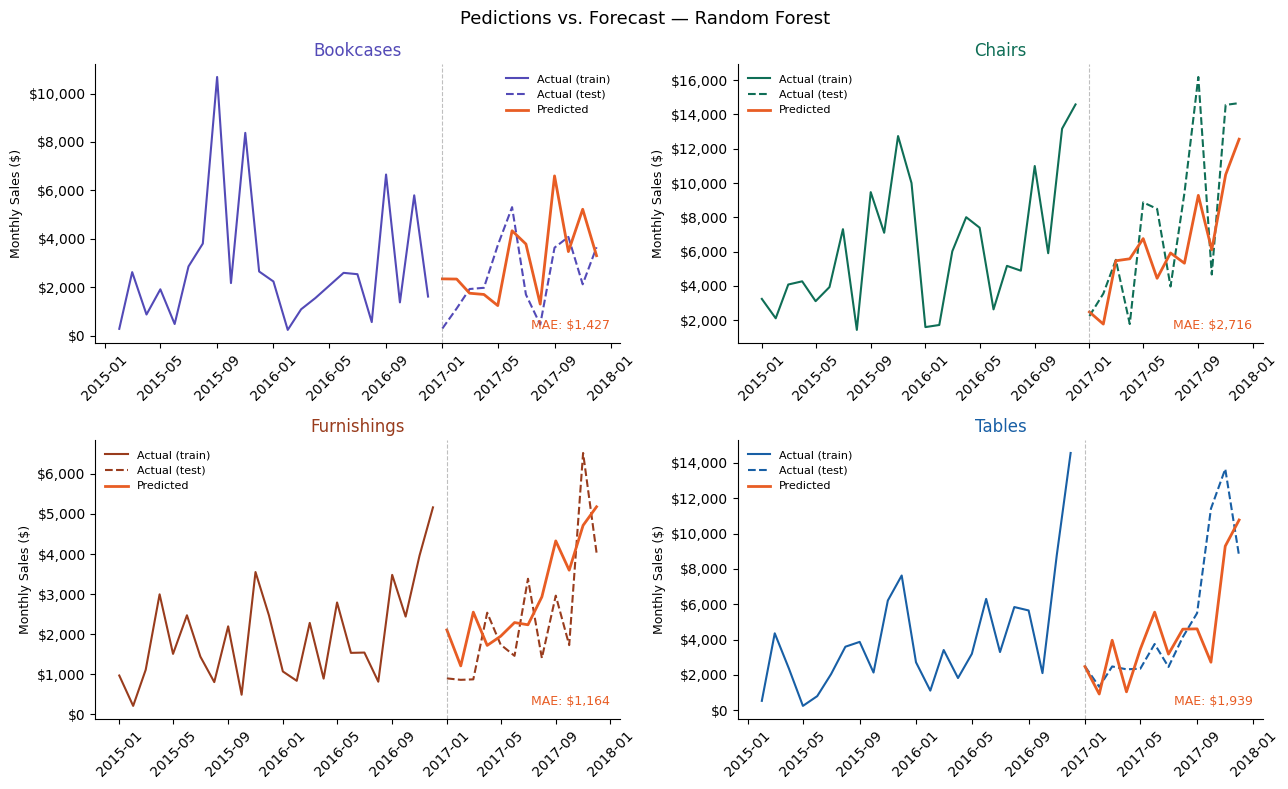

In [69]:
# Plot the predictions so we can display the forecast visually.
test = test.copy()
test["predictions"] = preds

subcat_cols = [c for c in test.columns if c.startswith("sub_category_")]
test["sub_category"] = test[subcat_cols].idxmax(axis=1).str.replace("sub_category_", "")
test.loc[test[subcat_cols].sum(axis=1) == 0, "sub_category"] = (
    "Bookcases"  # reference category
)

palette = {
    "Bookcases": "#534AB7",
    "Chairs": "#0F6E56",
    "Furnishings": "#993C1D",
    "Tables": "#185FA5",
}
subcats = sorted(test["sub_category"].unique())

fig, axes = plt.subplots(2, 2, figsize=(13, 8), facecolor="white")
axes = axes.flatten()

for i, subcat in enumerate(subcats):
    ax = axes[i]
    tr = train.copy()
    tr["sub_category"] = tr[subcat_cols].idxmax(axis=1).str.replace("sub_category_", "")
    tr.loc[tr[subcat_cols].sum(axis=1) == 0, "sub_category"] = "Bookcases"

    tr_sub = tr[tr["sub_category"] == subcat].sort_values("month")
    te_sub = test[test["sub_category"] == subcat].sort_values("month")
    c = palette[subcat]

    ax.plot(tr_sub["month"], tr_sub["sales"], color=c, lw=1.5, label="Actual (train)")
    ax.plot(
        te_sub["month"],
        te_sub["sales"],
        color=c,
        lw=1.5,
        linestyle="--",
        label="Actual (test)",
    )
    ax.plot(
        te_sub["month"], te_sub["predictions"], color="#E85D24", lw=2, label="Predicted"
    )
    ax.axvline(
        pd.Timestamp("2017-01-01"), color="gray", lw=0.8, linestyle="--", alpha=0.5
    )

    mae_sub = mean_absolute_error(te_sub["sales"], te_sub["predictions"])
    ax.set_title(subcat, fontsize=12, fontweight="500", color=c)
    ax.set_ylabel("Monthly Sales ($)", fontsize=9)
    ax.legend(fontsize=8, frameon=False)
    ax.text(
        0.98,
        0.05,
        f"MAE: ${mae_sub:,.0f}",
        transform=ax.transAxes,
        ha="right",
        fontsize=9,
        color="#E85D24",
    )
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Pedictions vs. Forecast — Random Forest", fontsize=13, fontweight="500")
plt.tight_layout()
plt.savefig("forecast_results.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

One of the benefits of choosing to do a random forest is that we can use it to gain insights on which features were the most important so let's do that next. 

<Axes: xlabel='importance', ylabel='predictor'>

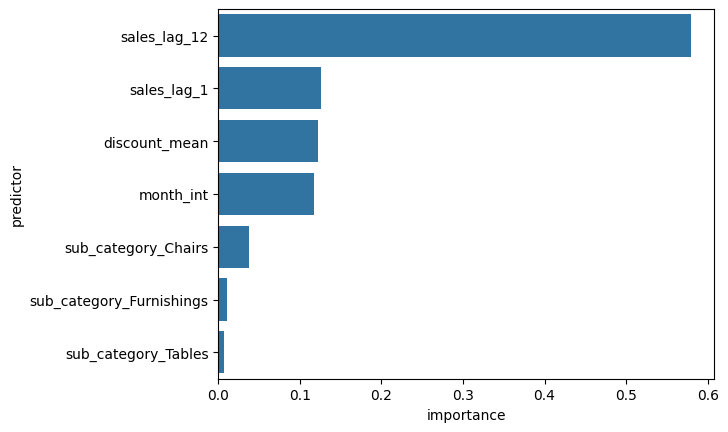

In [72]:
fi = pd.DataFrame(
    zip(FEAT_COLS, model.feature_importances_), columns=["predictor", "importance"]
)
sns.barplot(
    fi.sort_values("importance", ascending=False), y="predictor", x="importance"
)